In [1]:
##################################################################
# # ! Validation of Green's 3rd Identity using EROS shape model
##################################################################
# %%
# # ! Setup
import numpy as np
import matplotlib.pyplot as plt
import time
import pyvista as pv
pv.set_jupyter_backend('static')
from scipy.io import loadmat
from gravity_forward_numba import *

In [2]:
# # ! Parameters
radii = [17.8, 18.0, 20.0]        # Evaluation sphere radii (km)
icosph_lvl = 4                    # 10 * 4^n + 2
sub_max = 6                       # Max subdivision level for EROS mesh
NSUBs = np.arange(sub_max+1)      # Mesh refinement levels
rho = 2670.0                      # Density (kg/m^3)

In [3]:
# # ! Load EROS shape model from MAT file
eros_mat = loadmat('input/EROS.mat')
eros_vf = eros_mat['eros856_1708']  # First nV rows: vertices; last nF rows: faces
nF = 1708
nVpF = eros_vf.shape[0]
nV = nVpF - nF
Verts = eros_vf[:nV, :].astype(np.float64)
Faces = eros_vf[nV:, :].astype(np.int64)
pv_faces = np.column_stack([np.full(nF, 3, dtype=np.int32), Faces])
eros_base = pv.PolyData(Verts, pv_faces)

In [4]:
# # ! Generate evaluation points on concentric spheres (one per radius)
pts_Rs = []
for r in radii:
    unit_sph = pv.Icosphere(radius=1.0, nsub=icosph_lvl)
    pts = unit_sph.points * r
    pts_Rs.append(pts)

In [5]:
# # ! Compute reference (exact) gravity potential on each evaluation sphere
print("\nComputing exact gravitational potential on evaluation spheres...")
V_ref_Rs = []
t0_total = time.time()

for i, (r, pts) in enumerate(zip(radii, pts_Rs)):
    t0 = time.time()
    V_ref, *_ = WerSch_numba_v2(pts, Verts, Faces, rho)
    t_elapsed = time.time() - t0
    V_ref_Rs.append(V_ref)
    print(f" -> Radius {r} km: {len(pts)} points, time = {t_elapsed:.3f} s")

t_total = time.time() - t0_total
print(f"Total time for exact potential computation: {t_total:.3f} s")


Computing exact gravitational potential on evaluation spheres...
 -> Radius 17.8 km: 2562 points, time = 3.798 s
 -> Radius 18.0 km: 2562 points, time = 0.022 s
 -> Radius 20.0 km: 2562 points, time = 0.020 s
Total time for exact potential computation: 3.841 s


In [6]:
# # ! Convergence study: loop over mesh refinement levels
cvg_summary = []  # Store error metrics per refinement level
for nsub in NSUBs:
    print(f"\nProcessing subdivision level: {nsub}")
    
    # Refine mesh
    if nsub == 0:
        eros_sub = eros_base.copy()
    else:
        eros_sub = eros_base.subdivide(nsub, subfilter='linear')
    
    n_faces = eros_sub.n_cells
    print(f" -> Level {nsub} EROS refined mesh has {n_faces} faces")

    # Extract face geometry
    cfs = eros_sub.cell_centers().points
    nfs = eros_sub.cell_normals
    area_fs = eros_sub.compute_cell_sizes()["Area"]

    # Compute exact field on face centers (for Green's identity)
    t0 = time.time()
    V_cfs, gx_cfs, gy_cfs, gz_cfs, *_ = WerSch_numba_v1(cfs, Verts, Faces, rho)
    g_cfs = np.column_stack((gx_cfs, gy_cfs, gz_cfs))
    t_cfs = time.time() - t0
    print(f" -> Time (Face center field computation): {t_cfs:.3f} s")

    # Evaluate Green's third identity potential on each sphere
    V_green_Rs = []
    t_green_total = 0.0
    for pts in pts_Rs:
        t0 = time.time()
        V_green = green_third_identity_potential_numba(
            cfs, nfs, area_fs, V_cfs, g_cfs, pts
        )
        t_green_total += time.time() - t0
        V_green_Rs.append(V_green)
    print(f" -> Time (Green's Third ID computation):  {t_green_total:.3f} s")

    # Compute relative errors
    rel_rms_errors = []
    rel_max_errors = []
    for i in range(len(radii)):
        V_ref = V_ref_Rs[i]
        V_green = V_green_Rs[i]
        diff = V_green - V_ref

        rms_diff = np.sqrt(np.mean(diff**2))
        rms_exact = np.sqrt(np.mean(V_ref**2))
        rel_rms = rms_diff / rms_exact
        rel_max = np.max(np.abs(diff/V_ref))

        rel_rms_errors.append(rel_rms)
        rel_max_errors.append(rel_max)

    cvg_summary.append({
        'nsub': nsub,
        'n_faces': n_faces,
        'rel_rms': rel_rms_errors,
        'rel_max': rel_max_errors
    })


Processing subdivision level: 0
 -> Level 0 EROS refined mesh has 1708 faces
 -> Time (Face center field computation): 1.697 s
 -> Time (Green's Third ID computation):  0.278 s

Processing subdivision level: 1
 -> Level 1 EROS refined mesh has 6832 faces
 -> Time (Face center field computation): 0.033 s
 -> Time (Green's Third ID computation):  0.020 s

Processing subdivision level: 2
 -> Level 2 EROS refined mesh has 27328 faces
 -> Time (Face center field computation): 0.122 s
 -> Time (Green's Third ID computation):  0.060 s

Processing subdivision level: 3
 -> Level 3 EROS refined mesh has 109312 faces
 -> Time (Face center field computation): 0.469 s
 -> Time (Green's Third ID computation):  0.233 s

Processing subdivision level: 4
 -> Level 4 EROS refined mesh has 437248 faces
 -> Time (Face center field computation): 1.928 s
 -> Time (Green's Third ID computation):  1.060 s

Processing subdivision level: 5
 -> Level 5 EROS refined mesh has 1748992 faces
 -> Time (Face center fi

In [7]:
# # ! Print convergence table
print("\n" + "="*92)
print("Convergence of Green's Third ID Approximation")
print("Relative RMS and Maximum Errors vs. Eros Mesh Refinement")
print("="*92)
header1 = f"{'Nsub':>6} {'Faces':>8}" + "".join([f" {'RMS':>12} {'Max':>12}" for _ in radii])
header2 = " " * 15 + "".join([(" " * 10 + f"{r:.1f} km".center(16)) for r in radii])
print(header1)
print(header2)
print("-"*92)
for lvl_summary in cvg_summary:
    nsub = lvl_summary['nsub']
    n_faces = lvl_summary['n_faces']
    row = f"{nsub:6d} {n_faces:8d}"
    for i in range(len(radii)):
        rms = lvl_summary['rel_rms'][i]
        rmx = lvl_summary['rel_max'][i]
        row += f" {rms:12.2e} {rmx:12.2e}"
    print(row)
print("-"*92)
print("Note: All errors are relative (dimensionless).")


Convergence of Green's Third ID Approximation
Relative RMS and Maximum Errors vs. Eros Mesh Refinement
  Nsub    Faces          RMS          Max          RMS          Max          RMS          Max
                             17.8 km                   18.0 km                   20.0 km     
--------------------------------------------------------------------------------------------
     0     1708     6.86e-03     1.90e-01     3.08e-03     6.06e-02     2.21e-03     2.99e-03
     1     6832     1.32e-03     3.28e-02     6.79e-04     7.38e-03     6.28e-04     8.35e-04
     2    27328     2.05e-04     2.60e-03     1.82e-04     1.39e-03     1.76e-04     2.30e-04
     3   109312     5.36e-05     7.45e-04     4.99e-05     3.44e-04     4.84e-05     6.27e-05
     4   437248     1.44e-05     1.87e-04     1.36e-05     8.68e-05     1.32e-05     1.69e-05
     5  1748992     3.84e-06     4.69e-05     3.63e-06     2.20e-05     3.55e-06     4.51e-06
     6  6995968     9.95e-07     1.18e-05     9.46e

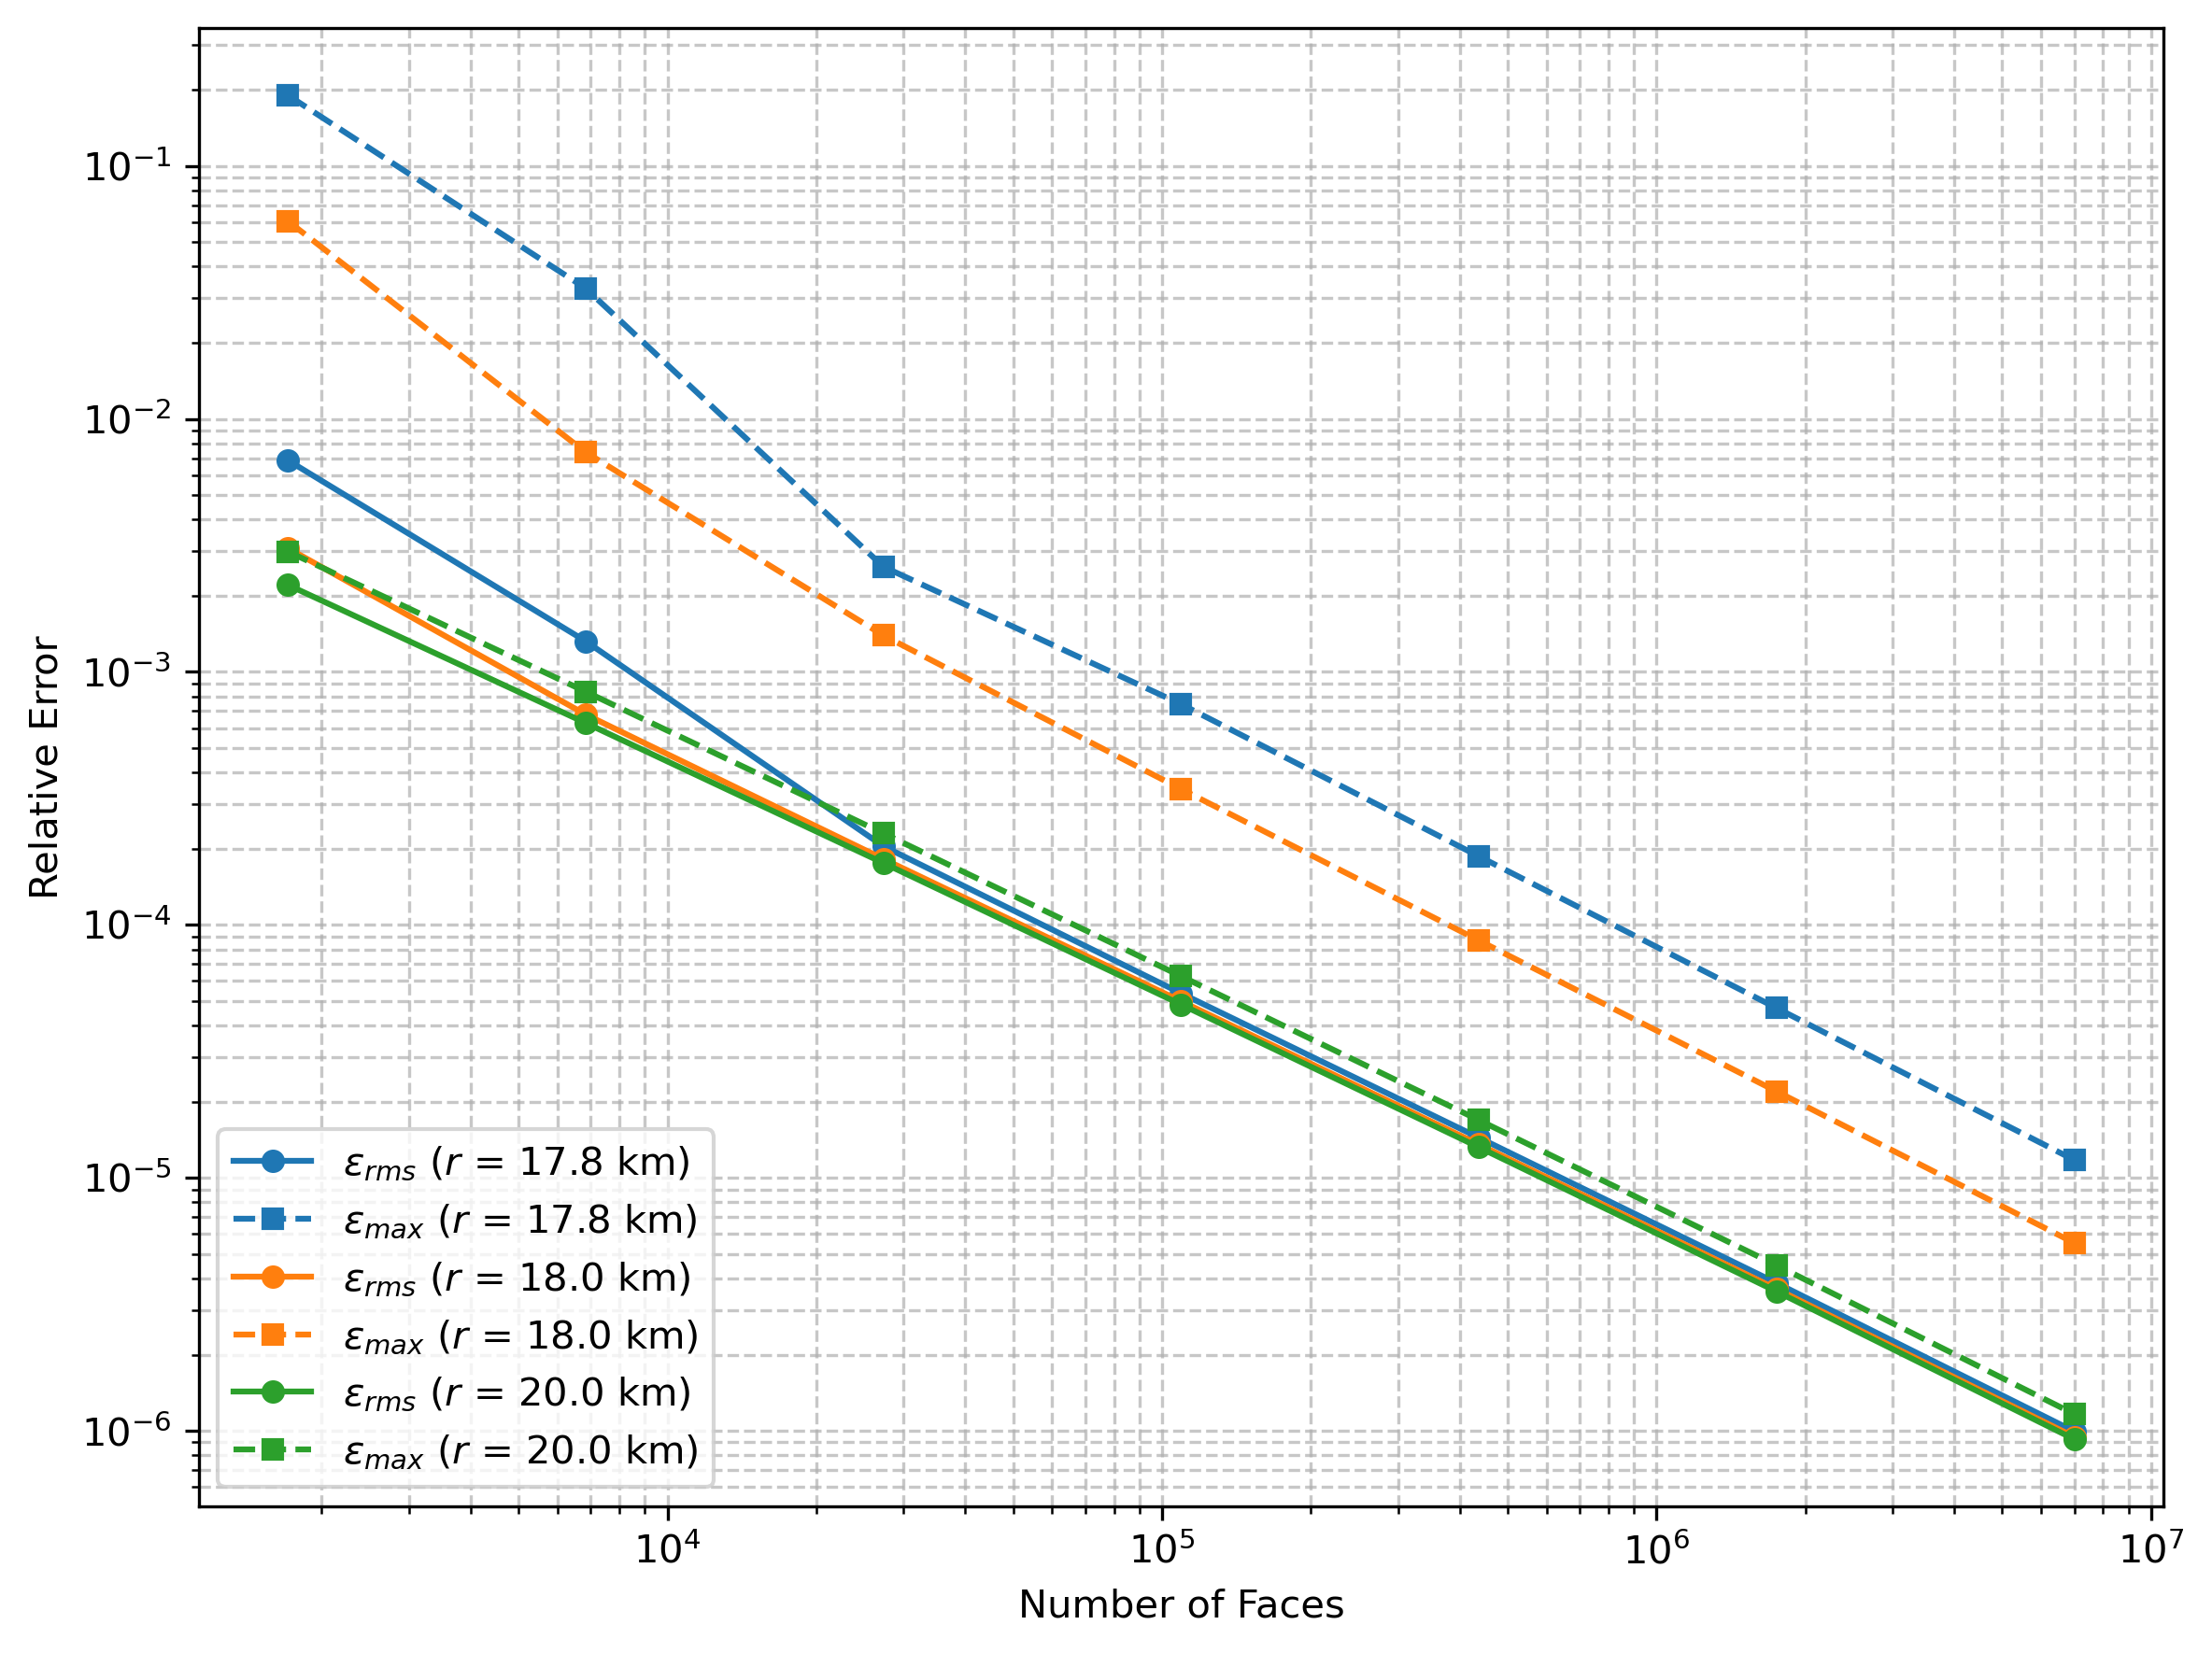

In [ ]:
# # ! Plot convergence
NFs = [lvl_summary['n_faces'] for lvl_summary in cvg_summary]
rel_RMS = np.array([lvl_summary['rel_rms'] for lvl_summary in cvg_summary])
rel_MAX = np.array([lvl_summary['rel_max'] for lvl_summary in cvg_summary])

plt.figure(figsize=(8, 6), dpi=300)
colors = ['tab:blue', 'tab:orange', 'tab:green']

for i, r in enumerate(radii):
    rms_vals = rel_RMS[:, i]
    max_vals = rel_MAX[:, i]
    color = colors[i % len(colors)]
    
    plt.loglog(NFs, rms_vals,
               marker='o', linestyle='-', color=color,
               label=f'$\epsilon_{{rms}}$ ($r$ = {r:.1f} km)', markersize=5)
    plt.loglog(NFs, max_vals,
               marker='s', linestyle='--', color=color,
               label=f'$\epsilon_{{max}}$ ($r$ = {r:.1f} km)', markersize=5)

plt.xlabel('Number of Faces')
plt.ylabel('Relative Error')
plt.grid(True, which="both", ls="--", alpha=0.7)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

Preparing error plot for subdivision level 0...
Preparing error plot for subdivision level 2...
Preparing error plot for subdivision level 4...
Preparing error plot for subdivision level 6...


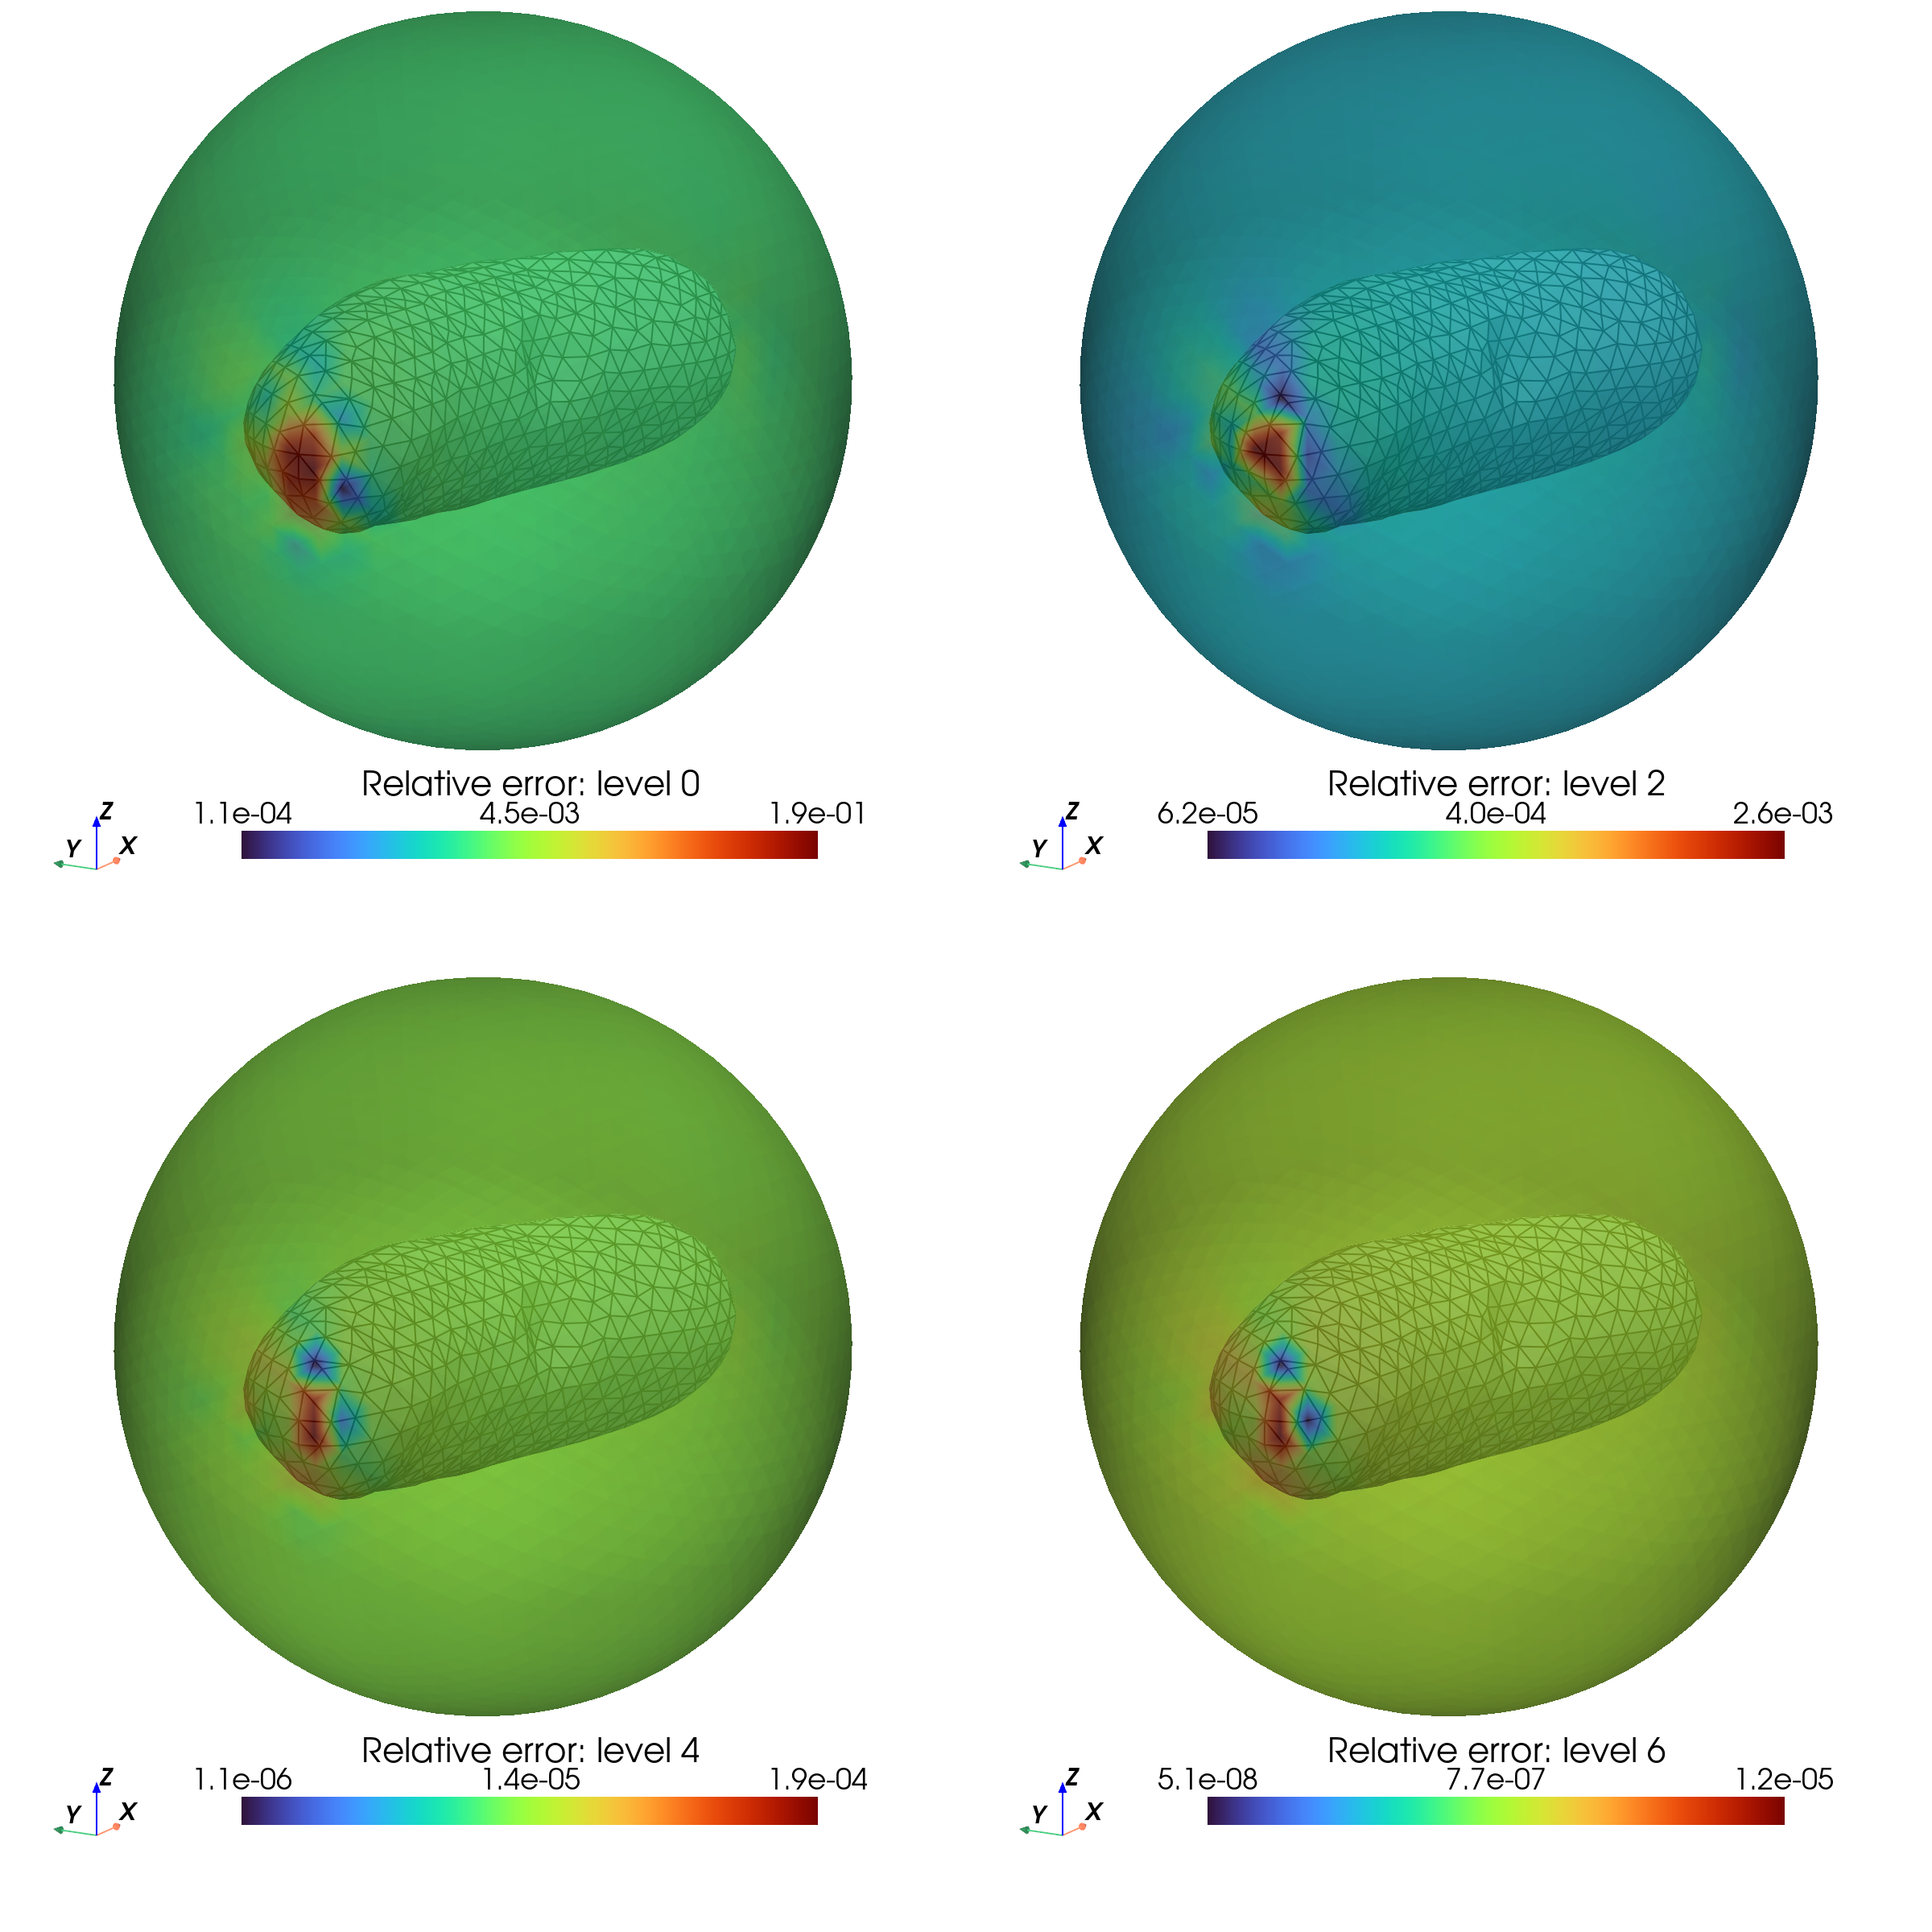

In [9]:
# # ! Visualize pointwise relative error across refinement levels
plot_nsubs = [0, 2, 4, 6]  # Choose 4 levels for 2x2 grid

pk_r = radii[0]
pts_pkr = pts_Rs[0]
V_ref_pkr = V_ref_Rs[0]

valid_sph = pv.Icosphere(radius=pk_r, nsub=icosph_lvl)

pl = pv.Plotter(shape=(2, 2), border=False, image_scale=3)
pl.set_background('white')

for plot_idx, nsub in enumerate(plot_nsubs):
    print(f"Preparing error plot for subdivision level {nsub}...")
    
    # Reconstruct refined mesh
    eros_sub = eros_base.subdivide(nsub, subfilter='linear')
    
    # Extract face data
    cfs = eros_sub.cell_centers().points
    nfs = eros_sub.face_normals
    area_fs = eros_sub.compute_cell_sizes()["Area"]
    
    # Compute exact field on face centers
    V_cfs, gx_cfs, gy_cfs, gz_cfs, *_ = WerSch_numba_v1(cfs, Verts, Faces, rho)
    g_cfs = np.column_stack((gx_cfs, gy_cfs, gz_cfs))
    
    # Evaluate Green's potential
    V_green_pkr = green_third_identity_potential_numba(
        cfs, nfs, area_fs, V_cfs, g_cfs, pts_pkr
    )
    
    # Compute pointwise relative error
    rel_error = np.abs(V_green_pkr - V_ref_pkr) / np.abs(V_ref_pkr)
    valid_sph[f'level{nsub}'] = rel_error
    
    # Plot EROS shape model and errors
    pl.subplot(plot_idx // 2, plot_idx % 2)
    pl.add_mesh(eros_base, color=None, show_edges=True, line_width=2)
    pl.add_mesh(valid_sph.copy(deep=False), scalars=f'level{nsub}', cmap='turbo',
                style='surface', opacity=0.75, log_scale=True, show_edges=False, show_scalar_bar=False)
    pl.add_scalar_bar(title=f'Relative error: level {nsub}', 
                      title_font_size=14, label_font_size=12,
                      position_x=0.25, position_y=0.11,  
                      n_labels=3, fmt='%.1e')
    pl.add_axes(label_size=(0.1/3, 0.1/3))

# Set camera
camera_config = dict(azimuth = 210, elevation = 15.0, distance = 90.0,
                     pan_x = 0, pan_y = 0.0, pan_z = -5.0)
pl.link_views()

az = np.deg2rad(camera_config['azimuth'])
el = np.deg2rad(camera_config['elevation'])
dist = camera_config['distance']

scene_center = np.array(pl.center)  # PyVista's bounding box center
focal_point = scene_center + np.array([
    camera_config['pan_x'],
    camera_config['pan_y'],
    camera_config['pan_z']
])

camera_position = focal_point + dist * np.array([
    np.cos(el) * np.cos(az),
    np.cos(el) * np.sin(az),
    np.sin(el)
])

pl.camera.position = camera_position
pl.camera.focal_point = focal_point
pl.camera.up = (0, 0, 1)

pl.window_size = (800, 800)

pl.show()